# Testing GPU

## Import TensorFlow and other libraries

In [23]:
import tensorflow as tf
from pathlib import Path
from matplotlib import pyplot as plt
import numpy as np

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [24]:
def normalize(input_image, real_image):
  input_image = (input_image / 127.5) - 1
  real_image = (real_image / 127.5) - 1
  return input_image, real_image

In [25]:
def plot_sample_sequence(sample_sequence):
    fig = plt.figure(figsize=(20, 4))
    for i, im in enumerate(sample_sequence):
        ax = fig.add_subplot(2,10,i+1)
        ax.imshow(im, cmap='gray') 
        ax.axis('off')
    plt.show()
    plt.close()

def sequence_generator(sample_sequence):
    for i in range(sample_sequence.shape[0]):
        yield sample_sequence[i, ...]

def plot_sequence(sample_sequence):
    plot_sample_sequence(sequence_generator(sample_sequence))

def inverse_sequence_generator(sample_sequence):
    for i in range(sample_sequence.shape[-1]):
        yield sample_sequence[..., i]

def plot_inverse_sequence(sample_sequence):
    plot_sample_sequence(inverse_sequence_generator(sample_sequence))

def plot_sequence_from_tensor(sample_sequence):
    if len(sample_sequence.shape) == 4 and sample_sequence.shape[0] == 1:
        plot_sample_sequence(inverse_sequence_generator(sample_sequence[0]))
    else:
        raise ValueError("The tensor must be of shape (1, height, width, channels)")

In [26]:
def ratio_std(previous, current):
  ratio = tf.math.divide_no_nan(current, previous)
  ratio = tf.reshape(ratio, [ratio.shape[0], ratio.shape[1]*ratio.shape[2]])
  return tf.math.reduce_std(ratio, axis=1)

def ratio_mean(previous, current):
  ratio = tf.math.divide_no_nan(current, previous)
  ratio = tf.reshape(ratio, [ratio.shape[0], ratio.shape[1]*ratio.shape[2]])
  return tf.math.reduce_mean(ratio, axis=1)

def ratio_sequences(previous, current):
  ratio = tf.math.divide_no_nan(current, previous)
  return tf.reshape(ratio, [ratio.shape[0], ratio.shape[1]*ratio.shape[2]])

def absolute_difference(previous, current):
  diff =  tf.math.abs(current-previous)
  diff = tf.reshape(diff, [diff.shape[0], diff.shape[1]*diff.shape[2]])
  return tf.math.reduce_mean(diff, axis=1)

def ratio_loss(y_true, y_pred):
  std_pred = []
  std_true = []
  for i in range(1, y_true.shape[-1]):
    std_pred.append(ratio_mean(y_pred[...,i-1], y_pred[...,i]))
    std_true.append(ratio_mean(y_true[...,i-1], y_true[...,i]))
  std_pred = tf.convert_to_tensor(std_pred, dtype=tf.float32)
  std_true = tf.convert_to_tensor(std_true, dtype=tf.float32)
  return tf.math.reduce_sum(tf.abs(std_true - std_pred))

def difference_loss(y_true, y_pred):
  mean_pred = []
  mean_true = []
  for i in range(1, y_true.shape[-1]):
    mean_pred.append(absolute_difference(y_pred[...,i-1], y_pred[...,i]))
    mean_true.append(absolute_difference(y_true[...,i-1], y_true[...,i]))
  mean_pred = tf.convert_to_tensor(mean_pred, dtype=tf.float32)
  mean_true = tf.convert_to_tensor(mean_true, dtype=tf.float32)
  return tf.math.reduce_sum(tf.abs(mean_true - mean_pred))

In [27]:
a = np.array([
        [
            [
                [1., 1., 1.],
                [1., 1., 1.],
                [1., 1., 1.],
            ],
            [
                [4., 4., 4.],
                [4., 4., 4.],
                [4., 4., 4.],
            ],
            [
                [4., 4., 4.],
                [4., 4., 4.],
                [4., 4., 4.],
            ],
            [
                [2., 2., 2.],
                [2., 2., 2.],
                [2., 2., 2.],
            ],
        ],
        [
            [
                [1., 1., 1.],
                [1., 1., 1.],
                [1., 1., 1.],
            ],
            [
                [4., 4., 4.],
                [4., 4., 4.],
                [4., 4., 4.],
            ],
            [
                [4., 4., 4.],
                [4., 4., 4.],
                [4., 4., 4.],
            ],
            [
                [2., 2., 2.],
                [2., 2., 2.],
                [2., 2., 2.],
            ],
        ]
    ])

b = np.array([
        [
            [
                [1., 1., 1.],
                [1., 1., 1.],
                [1., 1., 1.],
            ],
            [
                [2., 2., 2.],
                [2., 2., 2.],
                [2., 2., 2.],
            ],
            [
                [4., 4., 4.],
                [4., 4., 4.],
                [4., 4., 4.],
            ],
            [
                [3., 3., 3.],
                [3., 3., 3.],
                [3., 3., 3.],
            ],
        ],
        [
            [
                [1., 1., 1.],
                [1., 1., 1.],
                [1., 1., 1.],
            ],
            [
                [3., 3., 3.],
                [3., 3., 3.],
                [3., 3., 3.],
            ],
            [
                [4., 4., 4.],
                [4., 4., 4.],
                [4., 4., 4.],
            ],
            [
                [3., 3., 3.],
                [3., 3., 3.],
                [3., 3., 3.],
            ],
        ]
    ])
a = np.moveaxis(a, 1, -1)
b = np.moveaxis(b, 1, -1)
ratio_loss(a, b)

<tf.Tensor: shape=(), dtype=float32, numpy=4.8333335>

In [28]:
def get_sequence(sequence_number, sequences):
    current_sequence = sequences[:,sequence_number,...]
    current_sequence = current_sequence.astype(np.float32)
    current_sequence = np.expand_dims(current_sequence, axis=-1)
    current_sequence = np.moveaxis(current_sequence, -1, 0)
    current_sequence = np.moveaxis(current_sequence, 1, -1)
    return current_sequence

def move_pixels(sequence, number_of_pixels=1):
    s1 = np.roll(sequence, number_of_pixels, axis=1)
    s2 = np.roll(sequence, -number_of_pixels, axis=1)
    s3 = np.roll(sequence, number_of_pixels, axis=2)
    s4 = np.roll(sequence, -number_of_pixels, axis=2)
    return s1, s2, s3, s4

In [29]:
PATH = Path('/home/rafa/Sync/data/mnist_test_seq.npy')
sequences = np.load(PATH)

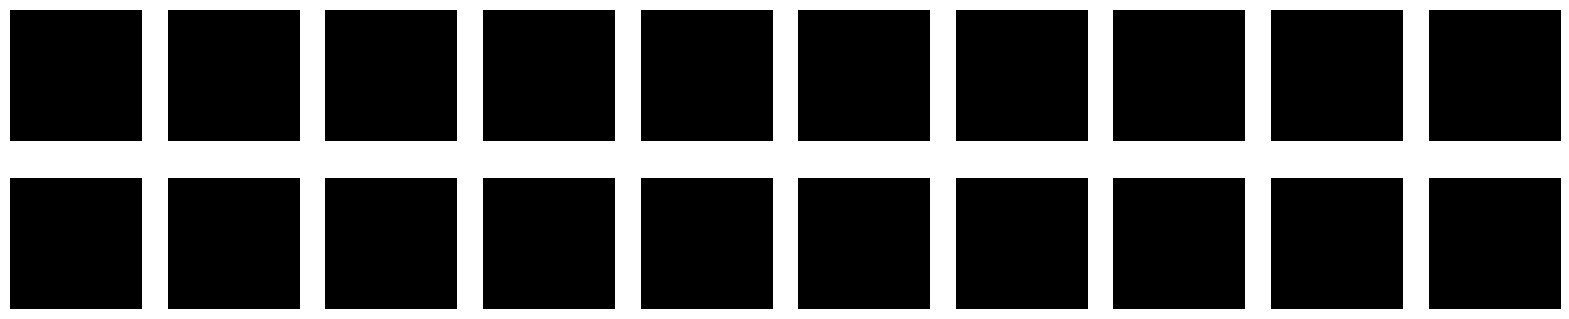

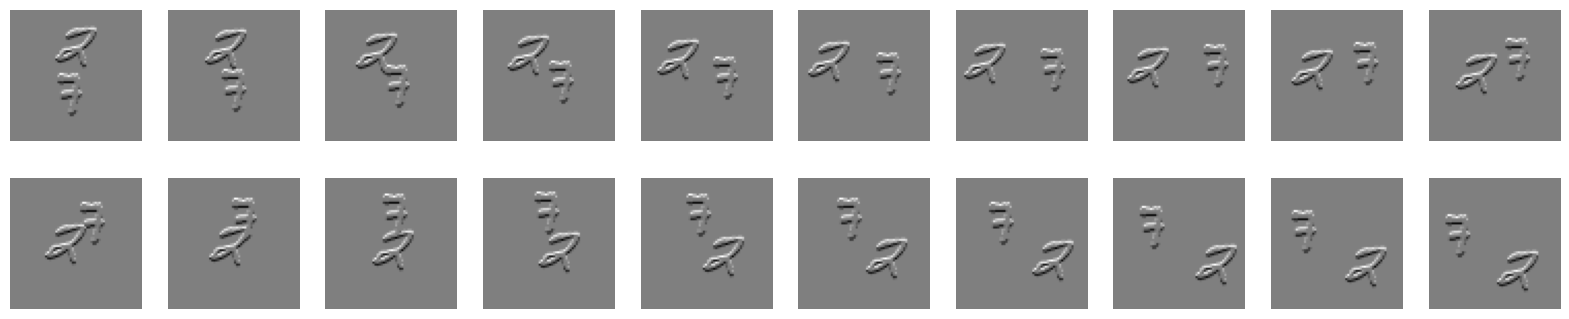

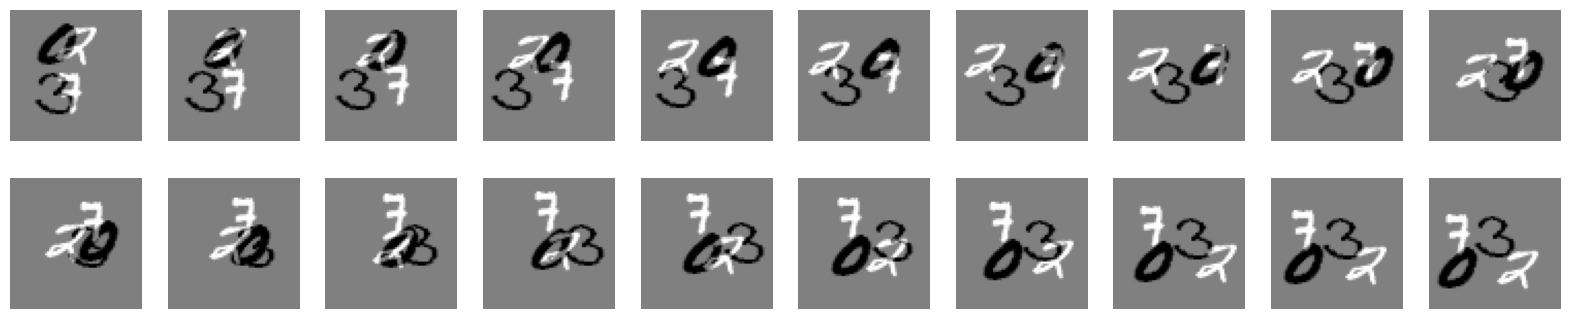

Absolute difference


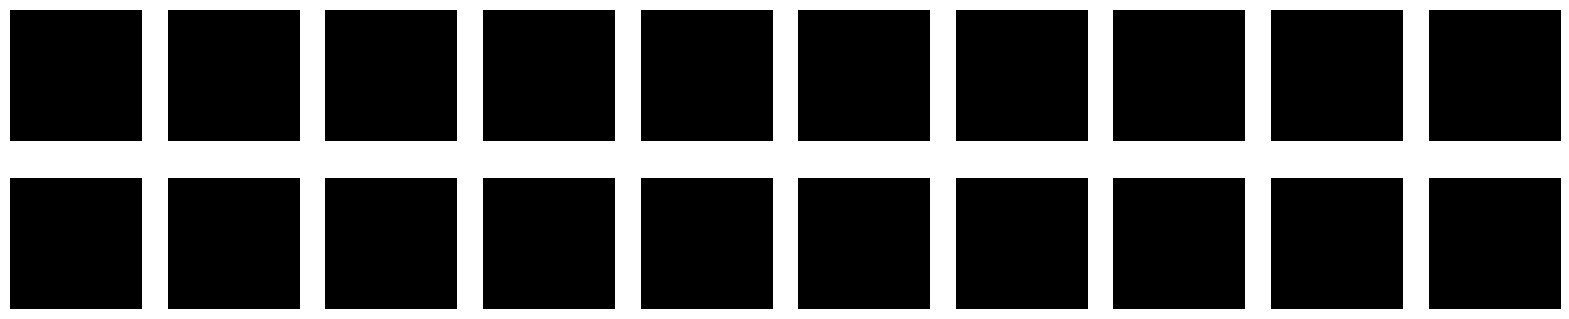

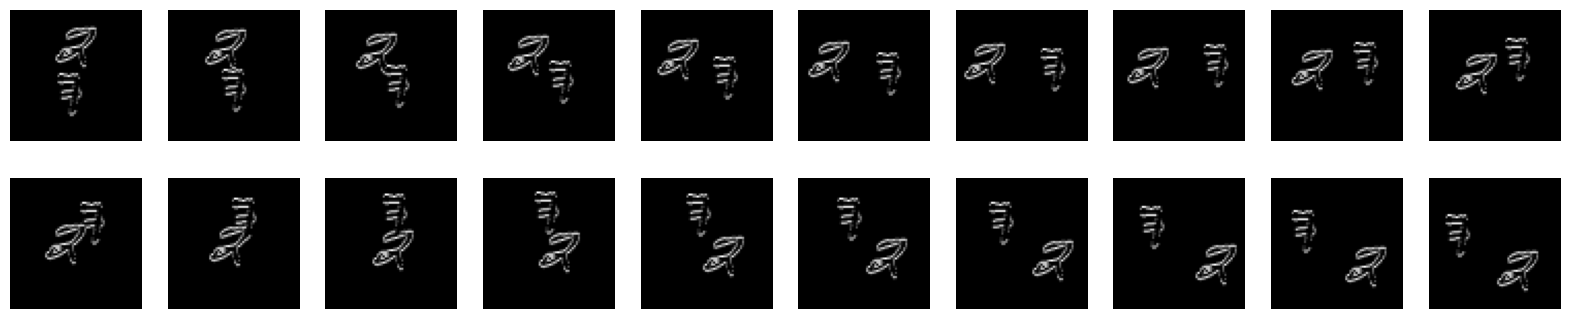

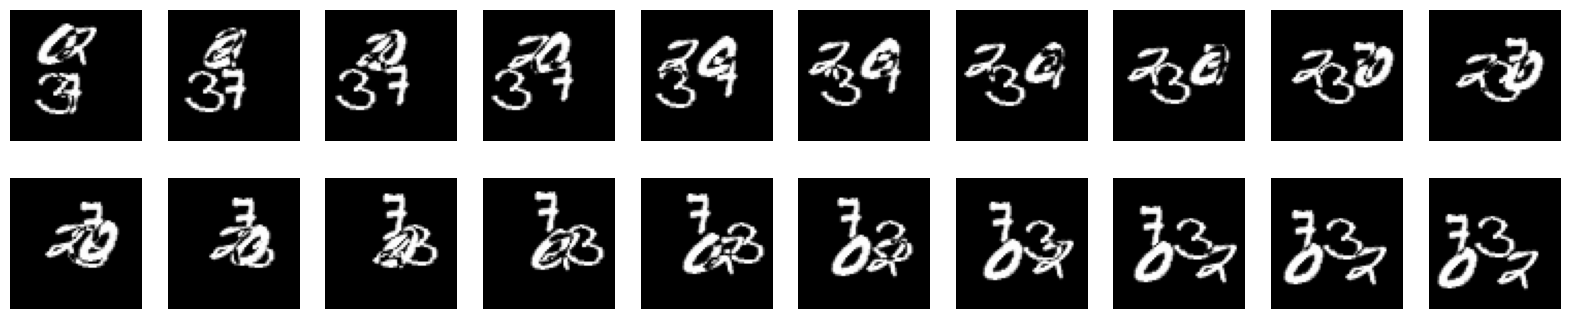

ratio


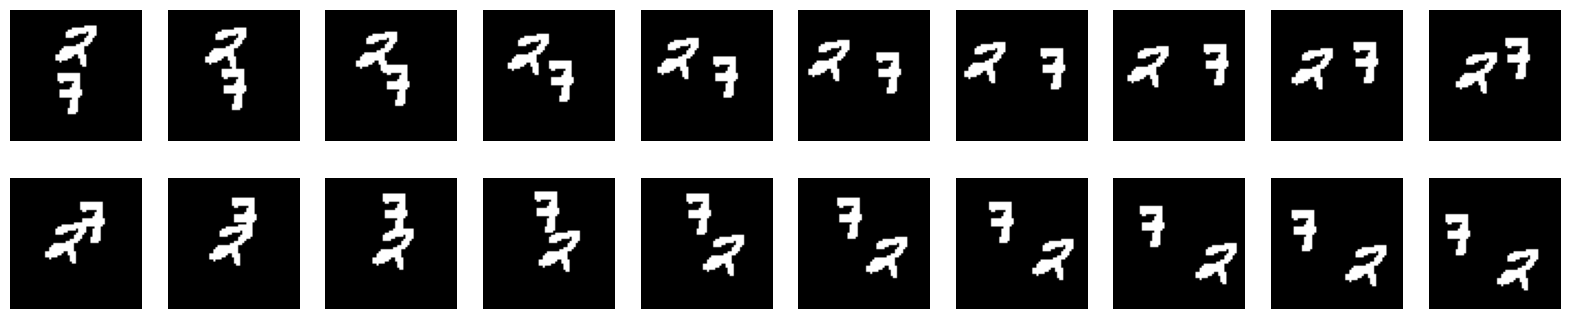

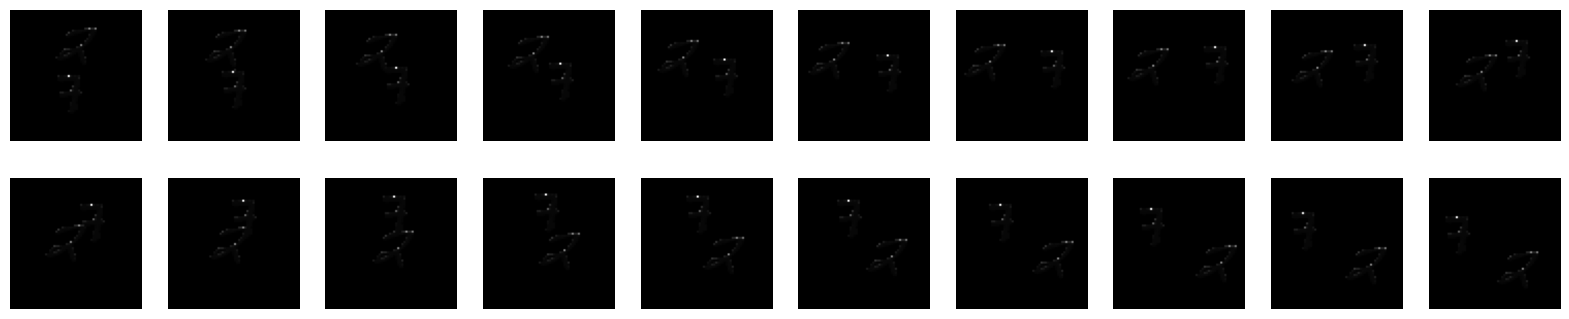

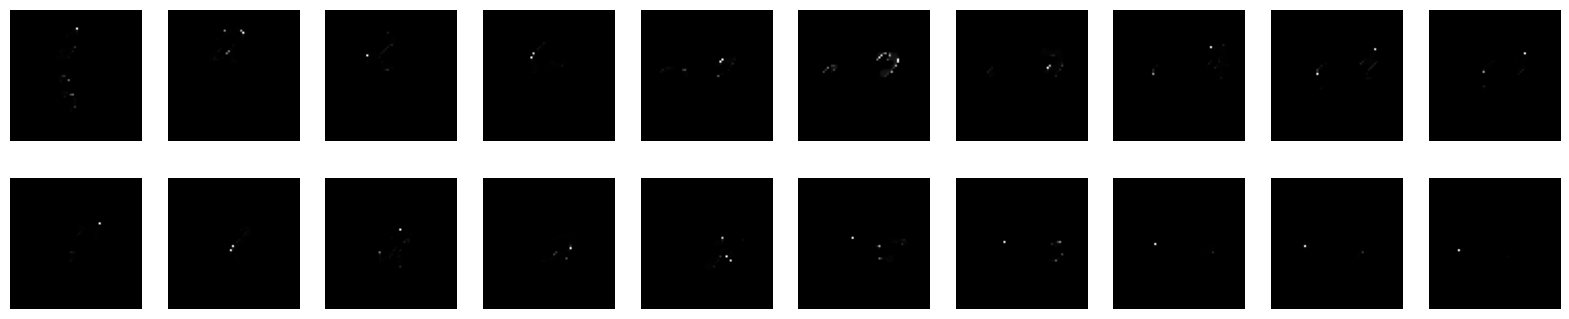

In [30]:


a = get_sequence(0, sequences)
b = get_sequence(1, sequences)

a1, a2, a3, a4 = move_pixels(a)
b1, b2, b3, b4 = move_pixels(b)
a5, a6, a7, a8 = move_pixels(a, number_of_pixels=2)
b5, b6, b7, b8 = move_pixels(b, number_of_pixels=2)

# print("a")
# plot_sequence_from_tensor(a)
# print("a1")
# plot_sequence_from_tensor(a1)
# print("a2")
# plot_sequence_from_tensor(a2)
# print("a3")
# plot_sequence_from_tensor(a3)
# print("a4")
# plot_sequence_from_tensor(a4)
# print("b")
# plot_sequence_from_tensor(b)
# print("b1")
# plot_sequence_from_tensor(b1)
# print("b2")
# plot_sequence_from_tensor(b2)
# print("b3")
# plot_sequence_from_tensor(b3)
# print("b4")
# plot_sequence_from_tensor(b4)
# print("a5")
# plot_sequence_from_tensor(a5)
# print("a6")
# plot_sequence_from_tensor(a6)
# print("a7")
# plot_sequence_from_tensor(a7)
# print("a8")
# plot_sequence_from_tensor(a8)
# print("b5")
# plot_sequence_from_tensor(b5)
# print("b6")
# plot_sequence_from_tensor(b6)
# print("b7")
# plot_sequence_from_tensor(b7)
# print("b8")
# plot_sequence_from_tensor(b8)
# print("a-a1")
plot_sequence_from_tensor(a-a)
plot_sequence_from_tensor(a-a1)
plot_sequence_from_tensor(a-b1)
print("Absolute difference")
plot_sequence_from_tensor(tf.math.abs(a-a))
plot_sequence_from_tensor(tf.math.abs(a-a1))
plot_sequence_from_tensor(tf.math.abs(a-b1))
print("ratio")
plot_sequence_from_tensor(tf.math.divide_no_nan(a, a))
plot_sequence_from_tensor(tf.math.divide_no_nan(a, a1))
plot_sequence_from_tensor(tf.math.divide_no_nan(a, b1))

In [31]:
print("a, a")
print(ratio_loss(a, a))
print("b, b")
print(ratio_loss(b, b))
print("a, b")
print(ratio_loss(a, b))
print("a, a1")
print(ratio_loss(a, a1))
print("a, a2")
print(ratio_loss(a, a2))
print("a, a3")
print(ratio_loss(a, a3))
print("a, a4")
print(ratio_loss(a, a4))
print("a, b1")
print(ratio_loss(a, b1))
print("a, b2")
print(ratio_loss(a, b2))
print("a, b3")
print(ratio_loss(a, b3))
print("a, b4")
print(ratio_loss(a, b4))
print("a, a5")
print(ratio_loss(a, a5))
print("a, a6")
print(ratio_loss(a, a6))
print("a, a7")
print(ratio_loss(a, a7))
print("a, a8")
print(ratio_loss(a, a8))

a, a
tf.Tensor(0.0, shape=(), dtype=float32)
b, b
tf.Tensor(0.0, shape=(), dtype=float32)
a, b
tf.Tensor(3.2915058, shape=(), dtype=float32)
a, a1
tf.Tensor(5.9604645e-08, shape=(), dtype=float32)
a, a2
tf.Tensor(7.4505806e-08, shape=(), dtype=float32)
a, a3
tf.Tensor(5.2154064e-08, shape=(), dtype=float32)
a, a4
tf.Tensor(4.4703484e-08, shape=(), dtype=float32)
a, b1
tf.Tensor(3.2915058, shape=(), dtype=float32)
a, b2
tf.Tensor(3.2915058, shape=(), dtype=float32)
a, b3
tf.Tensor(3.2915058, shape=(), dtype=float32)
a, b4
tf.Tensor(3.2915058, shape=(), dtype=float32)
a, a5
tf.Tensor(7.4505806e-08, shape=(), dtype=float32)
a, a6
tf.Tensor(7.4505806e-08, shape=(), dtype=float32)
a, a7
tf.Tensor(6.7055225e-08, shape=(), dtype=float32)
a, a8
tf.Tensor(5.9604645e-08, shape=(), dtype=float32)


In [32]:
def move_pixels_per_frame(sequence, num_pixels=1):
    s1 = np.zeros_like(sequence)
    s2 = np.zeros_like(sequence)
    s3 = np.zeros_like(sequence)
    s4 = np.zeros_like(sequence)
    acumulated_shift = num_pixels
    for i in range(sequence.shape[-1]):
        s1[..., i] = np.roll(sequence[..., i], acumulated_shift, axis=1)
        s2[..., i] = np.roll(sequence[..., i], acumulated_shift, axis=1)
        s3[..., i] = np.roll(sequence[..., i], acumulated_shift, axis=2)
        s4[..., i] = np.roll(sequence[..., i], acumulated_shift, axis=2)
        acumulated_shift += num_pixels
    return s1, s2, s3, s4

Difference


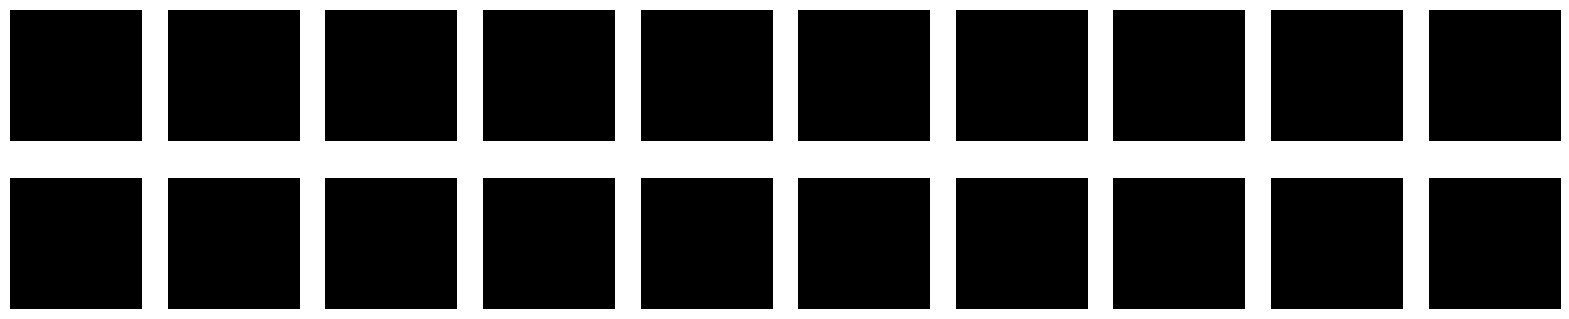

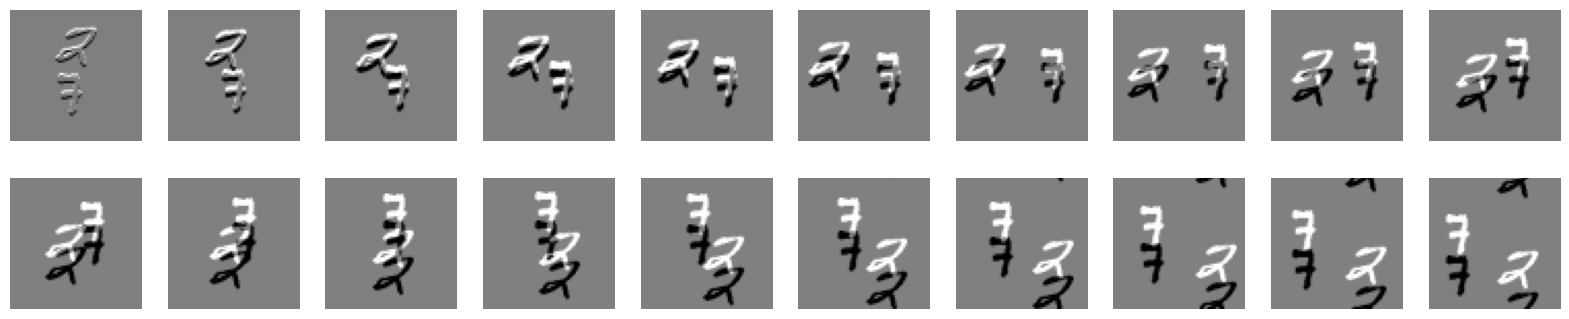

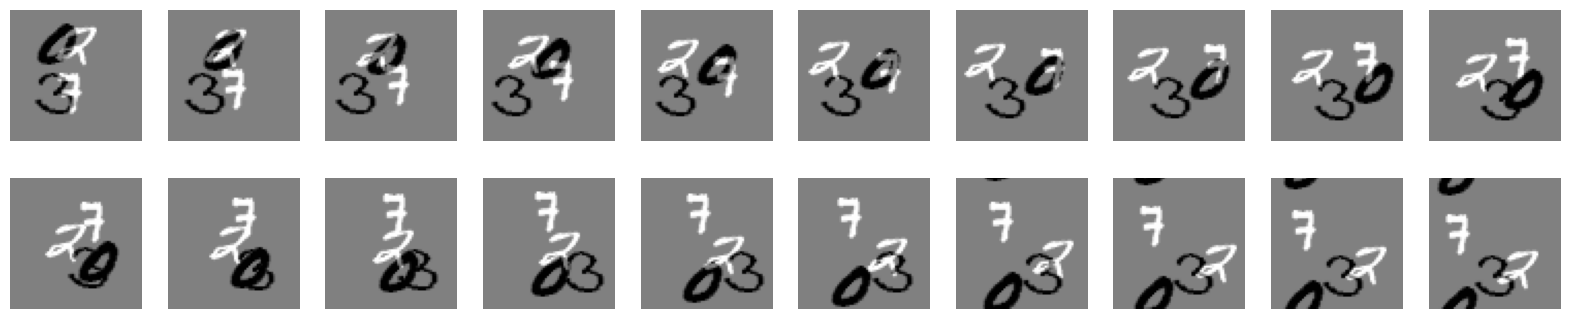

Absolute difference


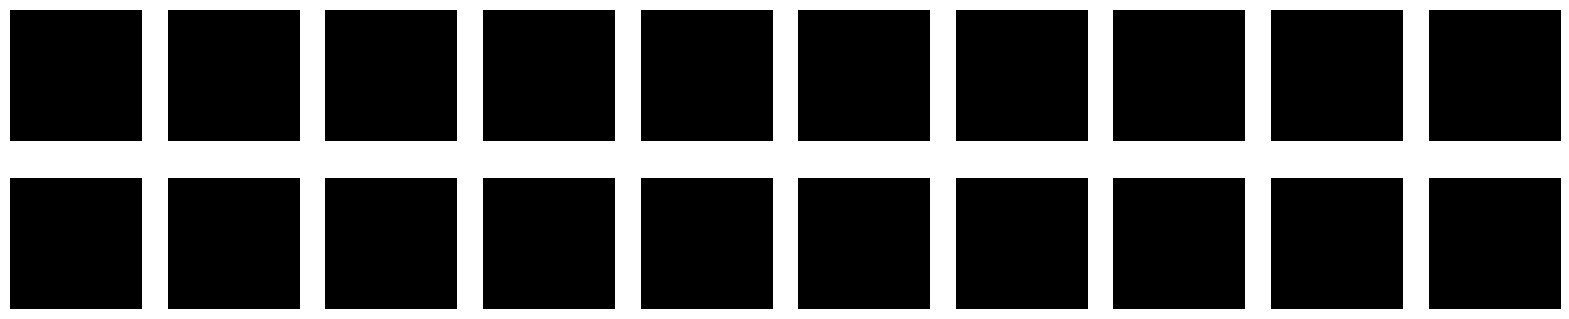

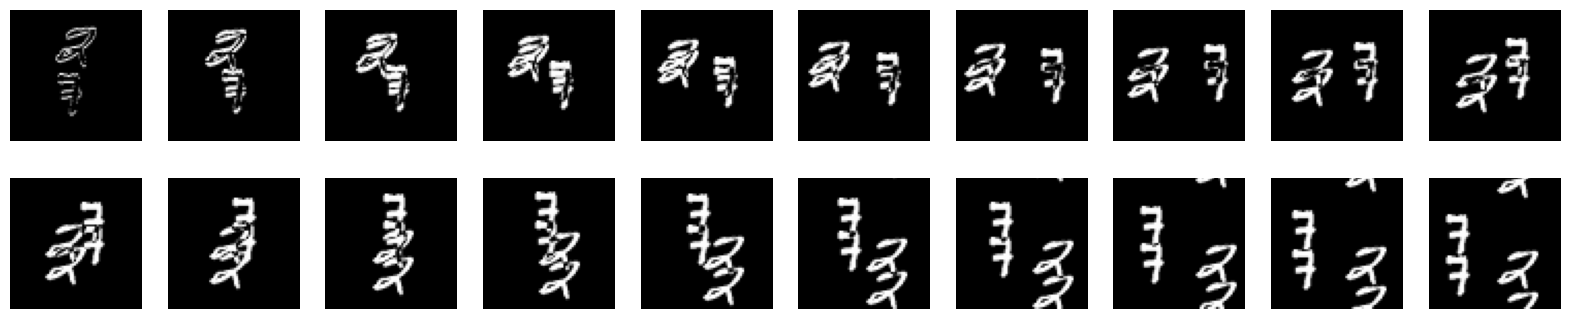

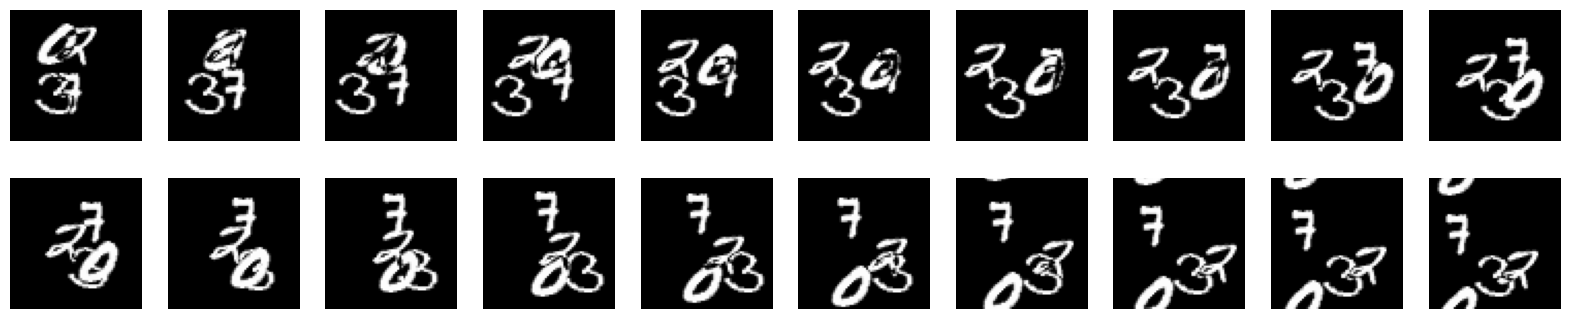

ratio


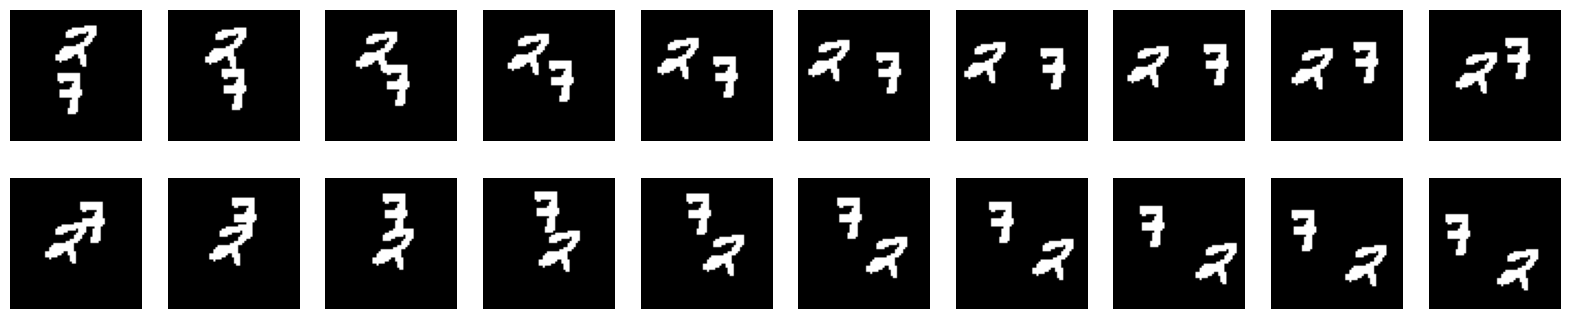

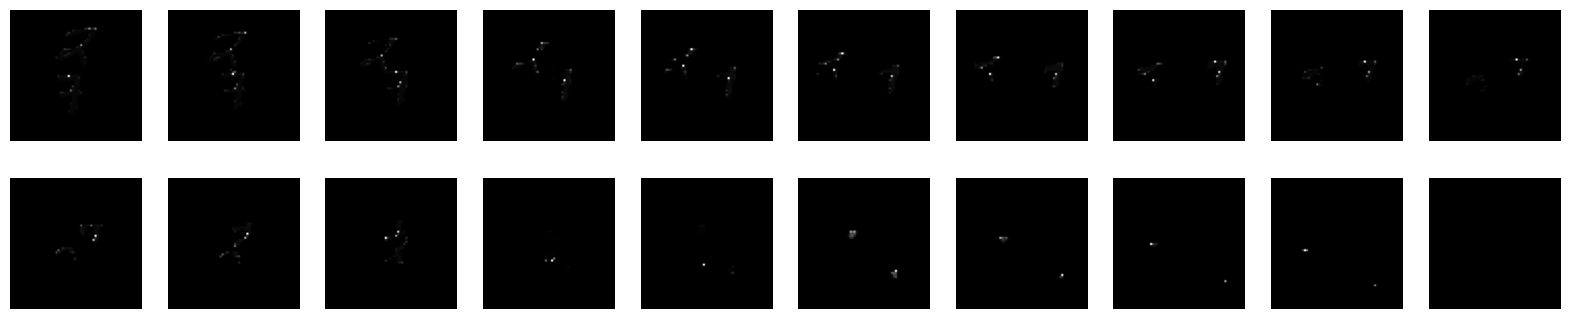

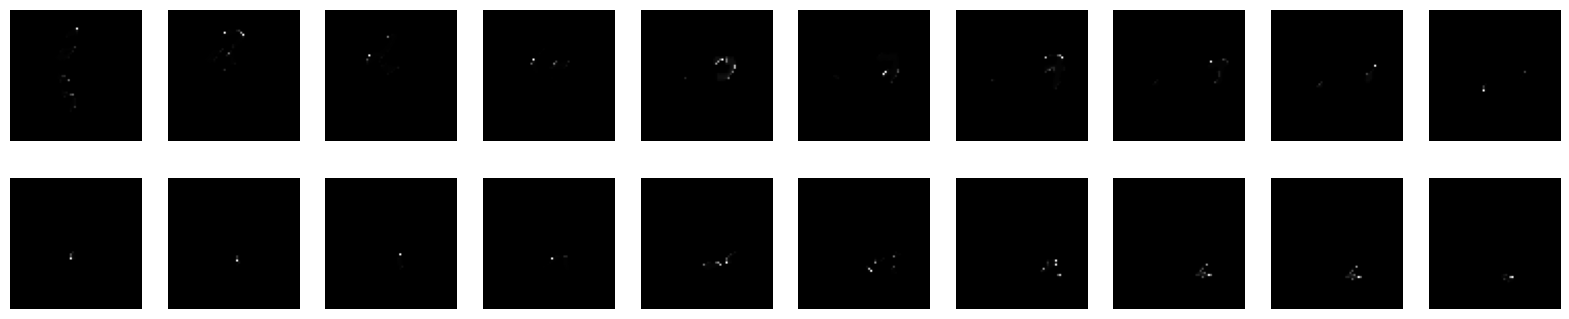

In [33]:
a1, a2, a3, a4 = move_pixels_per_frame(a)
b1, b2, b3, b4 = move_pixels_per_frame(b)
a5, a6, a7, a8 = move_pixels_per_frame(a, num_pixels=2)
b5, b6, b7, b8 = move_pixels_per_frame(b, num_pixels=2)

# print("a")
# plot_sequence_from_tensor(a)
# print("a1")
# plot_sequence_from_tensor(a1)
# print("a2")
# plot_sequence_from_tensor(a2)
# print("a3")
# plot_sequence_from_tensor(a3)
# print("a4")
# plot_sequence_from_tensor(a4)
# print("b")
# plot_sequence_from_tensor(b)
# print("b1")
# plot_sequence_from_tensor(b1)
# print("b2")
# plot_sequence_from_tensor(b2)
# print("b3")
# plot_sequence_from_tensor(b3)
# print("b4")
# plot_sequence_from_tensor(b4)
# print("a5")
# plot_sequence_from_tensor(a5)
# print("a6")
# plot_sequence_from_tensor(a6)
# print("a7")
# plot_sequence_from_tensor(a7)
# print("a8")
# plot_sequence_from_tensor(a8)
# print("b5")
# plot_sequence_from_tensor(b5)
# print("b6")
# plot_sequence_from_tensor(b6)
# print("b7")
# plot_sequence_from_tensor(b7)
# print("b8")
# plot_sequence_from_tensor(b8)
print("Difference")
plot_sequence_from_tensor(a-a)
plot_sequence_from_tensor(a-a1)
plot_sequence_from_tensor(a-b1)
print("Absolute difference")
plot_sequence_from_tensor(tf.math.abs(a-a))
plot_sequence_from_tensor(tf.math.abs(a-a1))
plot_sequence_from_tensor(tf.math.abs(a-b1))
print("ratio")
plot_sequence_from_tensor(tf.math.divide_no_nan(a, a))
plot_sequence_from_tensor(tf.math.divide_no_nan(a, a1))
plot_sequence_from_tensor(tf.math.divide_no_nan(a, b1))

In [34]:
print("a, a")
print(ratio_loss(a, a))
print("b, b")
print(ratio_loss(b, b))
print("a, b")
print(ratio_loss(a, b))
print("a, a1")
print(ratio_loss(a, a1))
print("a, a2")
print(ratio_loss(a, a2))
print("a, a3")
print(ratio_loss(a, a3))
print("a, a4")
print(ratio_loss(a, a4))
print("a, b1")
print(ratio_loss(a, b1))
print("a, b2")
print(ratio_loss(a, b2))
print("a, b3")
print(ratio_loss(a, b3))
print("a, b4")
print(ratio_loss(a, b4))
print("a, a5")
print(ratio_loss(a, a5))
print("a, a6")
print(ratio_loss(a, a6))
print("a, a7")
print(ratio_loss(a, a7))
print("a, a8")
print(ratio_loss(a, a8))

a, a
tf.Tensor(0.0, shape=(), dtype=float32)
b, b
tf.Tensor(0.0, shape=(), dtype=float32)
a, b
tf.Tensor(3.2915058, shape=(), dtype=float32)
a, a1
tf.Tensor(0.19922382, shape=(), dtype=float32)
a, a2
tf.Tensor(0.19922382, shape=(), dtype=float32)
a, a3
tf.Tensor(0.1729295, shape=(), dtype=float32)
a, a4
tf.Tensor(0.1729295, shape=(), dtype=float32)
a, b1
tf.Tensor(2.878608, shape=(), dtype=float32)
a, b2
tf.Tensor(2.878608, shape=(), dtype=float32)
a, b3
tf.Tensor(2.6763783, shape=(), dtype=float32)
a, b4
tf.Tensor(2.6763783, shape=(), dtype=float32)
a, a5
tf.Tensor(0.2890451, shape=(), dtype=float32)
a, a6
tf.Tensor(0.2890451, shape=(), dtype=float32)
a, a7
tf.Tensor(0.3193066, shape=(), dtype=float32)
a, a8
tf.Tensor(0.3193066, shape=(), dtype=float32)


In [35]:
# indice permutation of an array
print(np.arange(20))
idx = np.random.permutation(20)
idx = np.random.permutation(idx)

print(idx)
idx = np.random.permutation(idx)
print(idx)
idx = np.random.permutation(idx)
print(idx)
idx = np.random.permutation(idx)
print(idx)
idx = np.random.permutation(idx)
print(idx)
idx = np.random.permutation(idx)
print(idx)




[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
[17 13  4 14  6  1 16  2  8  7  0 15 11 19  3  5 10  9 12 18]
[19 12 11  5  8 10  6 16  0  4 18  9  1  3 14  2 13 17  7 15]
[11  3 10 17 12  6 15  7 16 13 14  9  5  2  1  4 18 19  0  8]
[ 1 14  9  2  3  7  4 18 12 15 19  6 17 10 11  8 13  5  0 16]
[ 1  2 19 16  4  5  3 13  0  6 12  9 10 14 18 15 11 17  7  8]
[18  1 17 11 15  7  2 13 16  8  9 10 14 19  5  6  0  3  4 12]


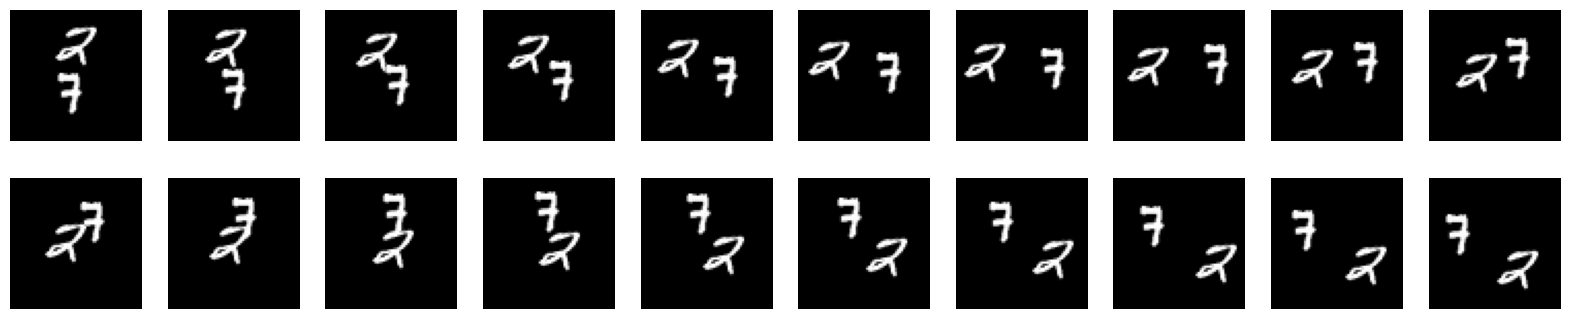

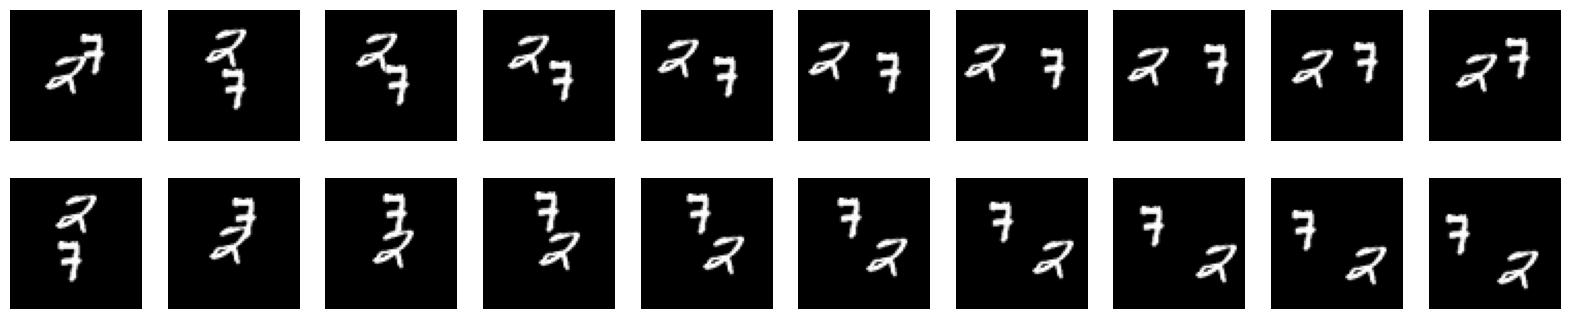

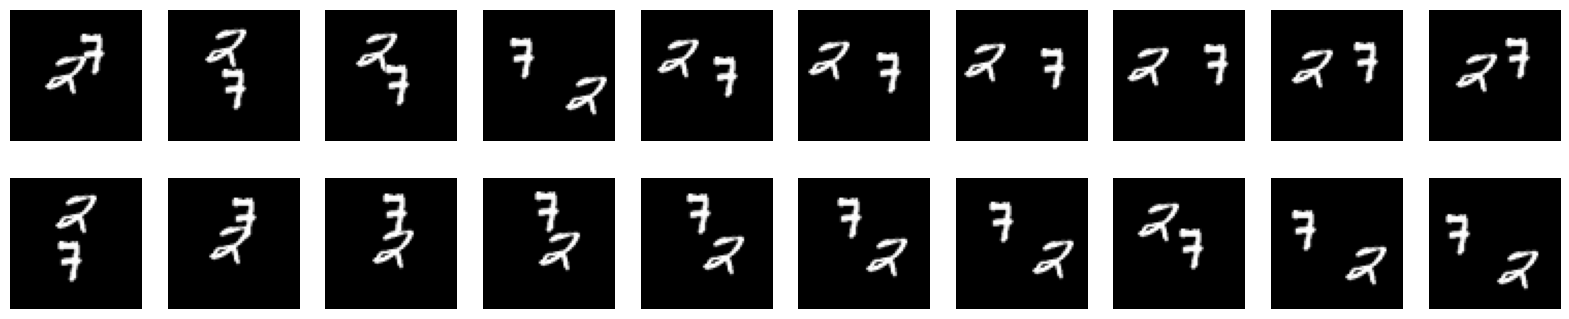

In [36]:
c1 = a[...,[10,1,2,3,4,5,6,7,8,9,0,11,12,13,14,15,16,17,18,19]]
c2 = a[...,[10,1,2,17,4,5,6,7,8,9,0,11,12,13,14,15,16,3,18,19]]
c3 = a[...,[10,1,2,17,4,12,6,7,8,9,0,11,5,13,14,15,16,3,18,19]]
c4 = a[...,[10,1,2,17,4,12,6,7,8,18,0,11,5,13,14,15,16,3,9,19]]
c5 = a[...,[8,18,16,7,10,0,4,14,15,17,19,6,13,1,12,2,3,5,11,9]]

plot_sequence_from_tensor(a)
plot_sequence_from_tensor(c1)
plot_sequence_from_tensor(c2)

In [37]:
print("a, a")
print(ratio_loss(a, a))
print("a, c1")
print(ratio_loss(a, c1))
print("a, c2")
print(ratio_loss(a, c2))
print("a, c3")
print(ratio_loss(a, c3))
print("a, c4")
print(ratio_loss(a, c4))
print("a, c5")
print(ratio_loss(a, c5))

a, a
tf.Tensor(0.0, shape=(), dtype=float32)
a, c1
tf.Tensor(0.097813636, shape=(), dtype=float32)
a, c2
tf.Tensor(0.21096966, shape=(), dtype=float32)
a, c3
tf.Tensor(0.5614543, shape=(), dtype=float32)
a, c4
tf.Tensor(0.84050924, shape=(), dtype=float32)
a, c5
tf.Tensor(0.8958996, shape=(), dtype=float32)


In [38]:
print("a, a")
print(difference_loss(a, a))
print("a, c1")
print(difference_loss(a, c1))
print("a, c2")
print(difference_loss(a, c2))
print("a, c3")
print(difference_loss(a, c3))
print("a, c4")
print(difference_loss(a, c4))
print("a, c5")
print(difference_loss(a, c5))

a, a
tf.Tensor(0.0, shape=(), dtype=float32)
a, c1
tf.Tensor(8.848389, shape=(), dtype=float32)
a, c2
tf.Tensor(25.123291, shape=(), dtype=float32)
a, c3
tf.Tensor(60.619873, shape=(), dtype=float32)
a, c4
tf.Tensor(79.06616, shape=(), dtype=float32)
a, c5
tf.Tensor(81.17676, shape=(), dtype=float32)
